# An example to run PolyChord Inference

The originals can be found in run_pypolychord.py in the source git repo

General Settings: param infos, directory, root

In [1]:
reload = 0
infos = [
  {'name':'Tcmb', 'min':0, 'max':10, 'latex':'T_{\mathrm{cmb}}'},
  {'name':'TR', 'min':0, 'max':10, 'latex':'T_{\mathrm{R}}'},
  {'name':'Beta', 'min':-10, 'max':10, 'latex':'\\beta'}]
direc = '/Users/cangtao/Desktop/tmp/test_polychord/'
root = 'arcade'

Intermediate settings: ndim, FileRoot, packages

In [2]:
ndim = len(infos)
FileRoot = direc + root
import numpy as np
import pypolychord
import PyLab as PL
import getdist
from getdist import plots
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': True,
    'font.family':'Times',
    'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}'})
%matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib widget

# Likelihood and prior

In [3]:
def Get_Arcade_Data():
    # Radio tempertures from Tab.4 of ARCADE2 paper (0901.0555), beware of the differences of antenna temp and thermo temp
    Arcade_Data = {
        'Frequency_GHz': np.array([0.022, 0.045, 0.408, 1.42, 3.2, 3.41, 7.97, 8.33, 9.72, 10.49, 29.5, 31, 90]),
        'Temperature_K': np.array([21200, 4355, 16.24, 3.213, 2.792, 2.771, 2.765, 2.741, 2.732, 2.732, 2.529, 2.573, 2.706]),
        'Uncertainty_K': np.array([5125, 520, 3.4, 0.53, 0.01, 0.009, 0.014, 0.016, 0.006, 0.006, 0.155, 0.076, 0.019])}
    return Arcade_Data
Arcade_Data = Get_Arcade_Data()

def model(Tcmb, TR, Beta):
    v = Arcade_Data['Frequency_GHz']
    v0 = 1.0
    T = Tcmb + TR*(v/v0)**Beta
    return T

def log_likelihood(theta):
    Tcmb, TR, Beta = theta
    T_data = Arcade_Data['Temperature_K']
    dt = Arcade_Data['Uncertainty_K']
    T_model = model(Tcmb, TR, Beta)
    Prefix = 1/np.sqrt(2.0*np.pi*dt**2.0)
    Chi2 = np.sum(((T_data-T_model)/dt)**2)
    LnL = - Chi2/2 + np.sum(np.log(Prefix))
    return LnL

def FlatPrior(cube):
    '''
    Converts a cube with values between 0-1 to physical parameters
    '''
    theta = []
    for idx in np.arange(0, len(cube)):
        theta.append(infos[idx]['min'] + cube[idx] * (infos[idx]['max'] - infos[idx]['min']))
    return theta

# I don't know what this does! Official doc says:
# Optional dumper function giving run-time read access to
# the live points, dead points, weights and evidences

def dumper(live, dead, logweights, logZ, logZerr):
    print("Last dead point:", dead[-1])


# Set up precision, full fileroot, etc

In [4]:
settings = pypolychord.settings.PolyChordSettings(nDims=ndim, nDerived=0) # We have no derived params, if you do checkout the official tutorial
settings.base_dir = direc
settings.file_root = root
settings.nlive = 50*ndim
settings.do_clustering = True
settings.read_resume = False
settings.feedback = 1

# Run PolyChord!

In [5]:
if reload:
    output = pypolychord.run_polychord(
        loglikelihood=log_likelihood,
        nDims = ndim,
        nDerived = 0,
        settings = settings,
        prior = FlatPrior,
        dumper = dumper)
    PL.print_mcmc_info(FileRoot = FileRoot, info = infos)

# Postprocessing

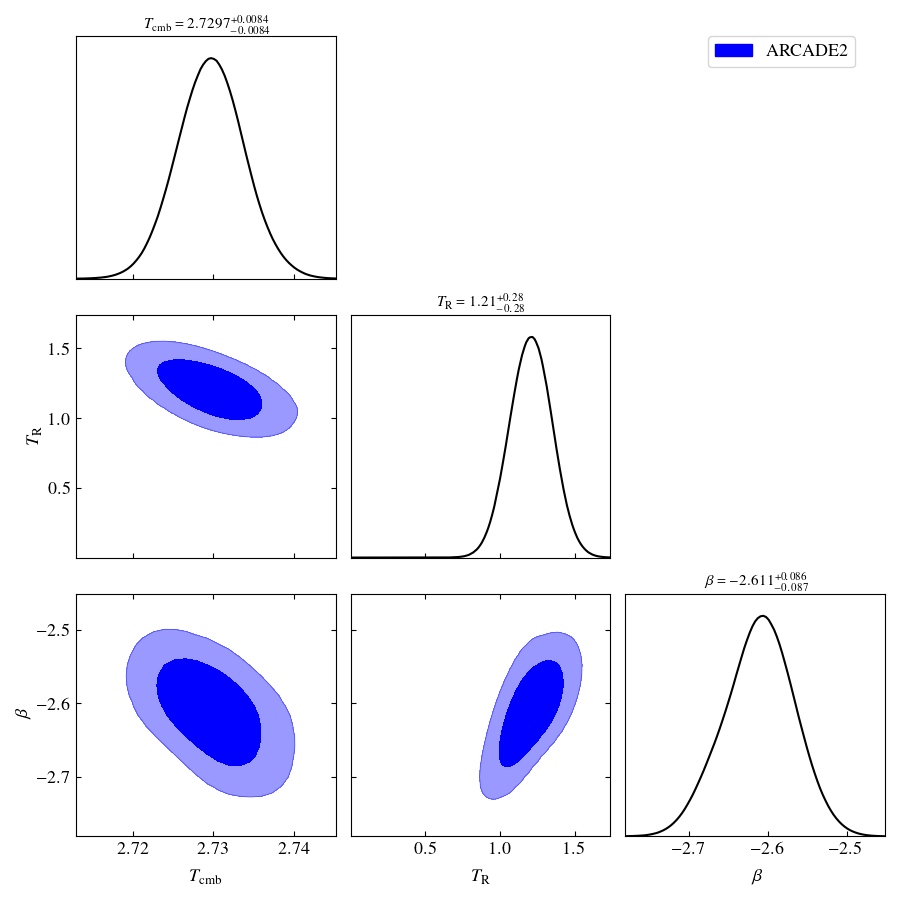

In [ ]:
samples = getdist.mcsamples.loadMCSamples(FileRoot)
p = samples.getParams()
g = plots.getSubplotPlotter(subplot_size = 3)
g.settings.axes_fontsize=14
g.settings.title_limit_fontsize = 12
g.settings.lab_fontsize =14
g.settings.axes_labelsize = 14
g.settings.legend_fontsize = 14

g.triangle_plot(
    samples,
    width_inch=12,
    contour_colors=['blue'],
    legend_labels=['ARCADE2'],
    filled = True,
    line_args=[{'lw':1.5,'ls':'-', 'color':'k'}],
    title_limit = 2,
    marker_args = {'lw' : 1.5},
    )

plt.tight_layout()
plt.savefig('/Users/cangtao/Desktop/tmp.pdf')


# Great! Now you know how to use PolyChord